# Labo 1 — Analyse : le comportement et les potentiels évoqués (décision lexicale, assis et en marche)

**PSY2007D, édition 2026.** Ce notebook part des fichiers EEG déjà prétraités de 10 participants (le pipeline v1.0 du projet Brain Walk,
avec la correction de l'accéléromètre non lissée ; le notebook `01_preprocessing_lexicaldecision.ipynb` montre comment). Il suit les étapes définies pour le labo :

1. **le comportement** : temps de réaction (TR), exactitude et IES, en barres ;
2. **les ERP moyens du groupe** dans une région du scalp ;
3. **les topographies** (cartes du scalp) ;
4. **l'amplitude et la latence** d'une composante dans une fenêtre de temps, en barres ;
5. **l'interaction** : l'effet de la fréquence (ou de la lexicalité) change-t-il quand on marche ?
6. **les corrélations** entre le comportement (TR ou IES) et l'EEG (amplitude ou latence), en nuage de points.

Chaque figure est accompagnée d'un **test statistique simple**.

**L'expérience.** Une suite de lettres apparaît : un mot fréquent (HF), un mot rare (LF) ou un pseudo-mot. La personne indique le plus vite
possible si c'est un mot du français, en touchant un côté d'une tablette (la **tape**). Elle fait 4 blocs assise et 4 blocs
en marchant sur un tapis roulant.

**Comment utiliser ce notebook.** Exécutez les cellules dans l'ordre (Maj + Entrée). **Bloc Type 1** : lisez et exécutez. **Bloc Type 2** :
changez un paramètre marqué `# modifiable` puis relancez la cellule et toutes celles qui suivent (menu *Exécuter* → *Exécuter la cellule
sélectionnée et toutes celles en dessous*). Tous vos choix sont réunis dans une seule cellule, à la section 0.4.

## 0. Mise en place (Bloc Type 1)

La cellule 0.1 télécharge les données du cours (855 Mo) depuis Google Drive et les décompresse dans `tasks/brainwalk/`, à côté du
notebook. Elle ne le fait qu'une fois : si les données sont déjà là, elle passe. Les quatre notebooks du labo (01, 09, 10 et 11) utilisent
ce même dossier. Il n'y a rien à télécharger à la main.

- **Sur votre ordinateur** : ouvrez le notebook depuis le dossier du dépôt cloné (`git clone`). Les données arrivent dans `tasks/brainwalk/`
  du dépôt, que Git ignore.
- **Dans Google Colab** : la cellule installe aussi MNE. Colab efface ses fichiers à la fin de la session : la cellule retélécharge alors
  les données (une ou deux minutes).

In [1]:
# ---- 0.1 Les données : téléchargées une seule fois, dans tasks/brainwalk à côté du notebook ---------------------------------------
import sys                                                   # pour savoir si le notebook tourne dans Google Colab
import zipfile                                               # pour décompresser les données
import urllib.request                                        # pour télécharger les données
from pathlib import Path                                     # pour écrire des chemins de fichiers
import hashlib                                               # pour reconnaître la version des données

EN_COLAB = 'google.colab' in sys.modules                     # True dans Google Colab, False sur votre ordinateur
if EN_COLAB:
    # Colab n'a pas MNE : on l'installe (environ une minute)
    !pip install -q mne
DOSSIER = Path('tasks/brainwalk')                            # ne pas modifier : les données, dans tasks/ à côté du notebook
ID_DRIVE = '19nnPiRuypz5fCPISybipdjxeop2EA_P8'               # ne pas modifier : le fichier labo1_donnees_2026.zip sur Google Drive
EMPREINTE = '123a0b4bc32ecf49'                               # ne pas modifier : l'empreinte de manifest.json dans cette version des données


def donnees_a_jour():
    """True si DOSSIER contient cette version des données (l'empreinte de son fichier manifest.json)."""
    manifeste = DOSSIER / 'manifest.json'
    return manifeste.exists() and hashlib.sha256(manifeste.read_bytes()).hexdigest()[:16] == EMPREINTE


def progression(blocs, taille_bloc, total):
    """Affiche l'avancement du téléchargement, tous les 10 %."""
    if total > 0 and blocs * taille_bloc * 10 // total > (blocs - 1) * taille_bloc * 10 // total:
        print(f'  {min(100, 100 * blocs * taille_bloc // total)} %')


if not donnees_a_jour():                                     # absentes, ou une ancienne version : on les télécharge (855 Mo)
    archive = DOSSIER.parent / 'labo1_donnees_2026.zip'
    archive.parent.mkdir(parents=True, exist_ok=True)
    print('Téléchargement des données depuis Google Drive (855 Mo, quelques minutes) :')
    urllib.request.urlretrieve(f'https://drive.usercontent.google.com/download?id={ID_DRIVE}&export=download&confirm=t', archive, progression)
    if not zipfile.is_zipfile(archive):                      # Google Drive a renvoyé une page web au lieu du fichier
        archive.unlink()
        raise RuntimeError('Google Drive n\'a pas envoyé les données (trop de téléchargements aujourd\'hui ?). Réessayez plus tard.')
    with zipfile.ZipFile(archive) as z:
        z.extractall(DOSSIER.parent)                         # crée tasks/brainwalk/
    archive.unlink()                                         # le zip ne sert plus
print('Données :', DOSSIER, '(prêtes)' if donnees_a_jour() else '(INTROUVABLES : relancez cette cellule)')

Données : tasks\brainwalk (prêtes)


In [2]:
# ---- 0.2 Les bibliothèques -------------------------------------------------------------------------------------------------------
import numpy as np                                           # calcul sur des tableaux de nombres
import pandas as pd                                          # tableaux de données (comme un tableur)
import matplotlib.pyplot as plt                              # figures
import mne                                                   # l'EEG
from scipy import stats                                      # les tests statistiques (t de Student, corrélations)

mne.set_log_level('ERROR')                                   # MNE n'affiche que les erreurs
print('MNE', mne.__version__)

MNE 1.13.2


### 0.3 Les données (Bloc Type 1)

**Les époques EEG** (`pretraite/sub-PXXX_epo.fif`, un fichier par participant) : un morceau de signal de -0,2 à 1,0 s autour de l'apparition
de chaque mot, pour les 19 électrodes. Seuls les essais **utilisables pour les ERP** sont là : réponse correcte, temps de réaction normal, EEG
sans artefact. Chaque époque porte un nom `posture/type` : `assis/HF`, `assis/LF`, `assis/pseudo`, `marche/HF`, `marche/LF`, `marche/pseudo`.
On choisit des époques par une partie du nom : `epochs['marche']` donne toutes les époques en marche, `epochs['HF']` tous les mots fréquents,
`epochs['assis/LF']` les mots rares en position assise.

**Les époques de la tape** (`pretraite/tape/sub-PXXX_tape_epo.fif`) : les mêmes essais, de -0,8 à 0,2 s autour de la tape (la réponse),
avec la même ligne de base que les époques du mot (-0,2 à 0 s avant le mot). Elles servent à la LPC, qui suit la décision plutôt que le
mot (notebook 01, section 13). Dans les deux fichiers, la colonne `sans_clignement` des métadonnées vaut `True` si aucun clignement n'a
son pic entre 0,25 s avant le mot et 0,25 s après la tape.

**Le comportement** (`comportement/essais.csv`) : tous les essais, une ligne par essai. `correct` vaut 1 ou 0 (vide pour une omission) ;
`tr_ms` est le temps de réaction ; `tr_valide` dit si ce temps entre dans la moyenne des TR (réponse correcte, au moins 250 ms, pas aberrante).

**Les électrodes reconstruites.** Une électrode qui n'a pas été mesurée dans une époque (morte, trop bruitée, ou trop grande dans cette
époque) y a été reconstruite à partir de ses voisines, pour garder une carte complète. La colonne `reconstruites` des métadonnées en donne
la liste pour chaque époque (par exemple `'Fp2 F7 P7'`). Une électrode reconstruite n'est pas une mesure : elle suit à peu près l'ERP moyen
de ses voisines, mais presque pas leur signal essai par essai (notebook 01, 11.10). Dans ce notebook, la valeur d'une région est donc, dans
chaque époque, la moyenne de ses seules électrodes mesurées, et les cartes n'ont de valeur qu'aux électrodes mesurées.

In [3]:
# ---- 0.3 Charger les données -----------------------------------------------------------------------------------------------------
epochs, epochs_tape = {}, {}                                 # participant -> ses époques autour du mot, et autour de la tape
for fichier in sorted((DOSSIER / 'pretraite').glob('sub-*_epo.fif')):
    participant = fichier.name.split('_')[0][4:]             # 'sub-P003_epo.fif' -> 'P003'
    epochs[participant] = mne.read_epochs(fichier, preload=True)
    fichier_tape = DOSSIER / 'pretraite' / 'tape' / f'sub-{participant}_tape_epo.fif'
    if fichier_tape.exists():
        epochs_tape[participant] = mne.read_epochs(fichier_tape, preload=True)
essais = pd.read_csv(DOSSIER / 'comportement' / 'essais.csv')
print(f'{len(epochs)} participants avec de l\'EEG ({len(epochs_tape)} avec les époques de la tape), {len(essais)} essais de comportement')
comptes = pd.DataFrame({p: ep.metadata.groupby(['posture', 'type']).size() for p, ep in epochs.items()}).T.fillna(0).astype(int)
comptes                                                      # le nombre d'époques par participant et condition

10 participants avec de l'EEG (10 avec les époques de la tape), 7400 essais de comportement


posture assis            marche           
type       HF  LF pseudo     HF  LF pseudo
P002       88  57    179     94  62    157
P003       97  73    188     84  69    164
P004       81  57    147     58  41    115
P005        0   0      0     49  44     89
P006       77  70    157      0   0      0
P007       98  89    131     63  59     77
P008       99  72    159     79  71    144
P009       94  60    180     79  57    133
P010       94  82    175     82  66    137
P012       93  93    185     95  91    183

**Que regarder ?** P005 n'a fait que les blocs en marche ; chez P006, aucune époque en marche n'est utilisable (le casque bougeait trop). Ces
deux participants ne peuvent pas entrer dans une comparaison assis contre marche.

### 0.4 Votre hypothèse et vos choix (Bloc Type 2)

Avant de regarder les résultats, **écrivez votre hypothèse et vos prédictions**.

- **H1, la posture.** Marcher en même temps demande de l'attention (une *double tâche*). Les réponses sont-elles plus lentes ou moins exactes
  en marche ? Les ERP sont-ils plus petits ou plus tardifs ?
- **H2, la fréquence des mots.** Un mot rare (LF) est plus difficile à reconnaître qu'un mot fréquent (HF). Les réponses sont-elles plus lentes
  et moins exactes ? La N400 est-elle plus grande (plus négative) pour les mots rares ?
- **H3, la lexicalité.** Un pseudo-mot (une suite de lettres qui se prononce, mais n'a pas de sens, comme *candre*) ne trouve rien dans le
  lexique. Les réponses sont-elles plus lentes ? La N400 est-elle plus grande (plus négative) pour les pseudo-mots que pour les mots
  (Kutas et Federmeier, 2011) ?

**Les composantes** (fenêtres et régions fixées *avant* de voir les données, d'après la littérature) :

| Composante | Fenêtre (amplitude) | Recherche du pic (latence) | Région | Ce qu'on en sait |
|---|---|---|---|---|
| P2 | 180 à 250 ms après le mot | 130 à 320 ms | Fz, Cz, F3, F4 | onde positive précoce, liée à l'attention et à l'analyse visuelle du mot |
| N400 | 300 à 500 ms après le mot | 250 à 650 ms | C3, Cz, C4, P3, Pz, P4 | onde négative, plus grande quand l'accès au sens d'un mot est difficile |
| LPC | de -100 à 0 ms par rapport à la tape | -500 à +100 ms (presque tout l'intervalle entre le mot et la tape) | P3, Pz, P4 | onde positive tardive, liée à la décision ; elle culmine vers la réponse (Twomey et al., 2015), d'où sa mesure autour de la tape |
| LPC (mot) | 500 à 800 ms après le mot | 400 à 900 ms | P3, Pz, P4 | la même onde, mesurée depuis le mot comme dans beaucoup d'études : elle y est étalée, parce que la tape arrive à un moment différent dans chaque essai |

**Les clignements.** On cligne souvent des yeux juste après avoir répondu ; la correction des yeux n'en enlève pas tout, et un clignement près
de la tape change la LPC (notebook 01, section 13). `SANS_CLIGNEMENT = True` ne garde que les essais sans clignement entre le mot et la tape.
Un effet sur la LPC se vérifie avec ce choix.

Choisir la fenêtre *après* avoir regardé les ERP, là où la différence est la plus grande, rend le test trop optimiste : on trouve un effet même
quand il n'y en a pas. Gardez les fenêtres de la littérature, ou justifiez votre choix avant de regarder.

In [4]:
# ---- 0.4 Vos choix ---------------------------------------------------------------------------------------------------------------
HYPOTHESE = 'posture'        # modifiable : 'posture' (assis / en marche), 'frequence' (mots fréquents / rares) ou 'lexicalite' (mots / pseudo-mots)
POSTURE = 'les deux'         # modifiable, pour 'frequence' et 'lexicalite' : 'les deux', 'assis' ou 'marche'
COMPOSANTE = 'P2'            # modifiable : 'P2', 'N400', 'LPC' (autour de la tape) ou 'LPC (mot)' (donne la fenêtre et la région)
SANS_CLIGNEMENT = False      # modifiable : True pour ne garder que les essais sans clignement entre le mot et la tape

COMPOSANTES = {                                              # ne pas modifier : les composantes du tableau ci-dessus ; centre : le zéro des temps
    'P2': dict(fenetre=(0.180, 0.250), region=['Fz', 'Cz', 'F3', 'F4'], polarite='positive', recherche=(0.130, 0.320), centre='mot'),
    'N400': dict(fenetre=(0.300, 0.500), region=['C3', 'Cz', 'C4', 'P3', 'Pz', 'P4'], polarite='negative', recherche=(0.250, 0.650), centre='mot'),
    'LPC': dict(fenetre=(-0.100, 0.0), region=['P3', 'Pz', 'P4'], polarite='positive', recherche=(-0.500, 0.100), centre='tape'),
    'LPC (mot)': dict(fenetre=(0.500, 0.800), region=['P3', 'Pz', 'P4'], polarite='positive', recherche=(0.400, 0.900), centre='mot'),
}
REGIONS = {'frontale': ['F3', 'Fz', 'F4'], 'centrale': ['C3', 'Cz', 'C4'], 'pariétale': ['P3', 'Pz', 'P4'],
           'occipitale': ['O1', 'O2'], 'temporale gauche': ['T7', 'P7'], 'temporale droite': ['T8', 'P8']}   # d'autres régions possibles
FENETRE = COMPOSANTES[COMPOSANTE]['fenetre']    # modifiable : ou votre fenêtre en secondes, par exemple (0.350, 0.450)
REGION = COMPOSANTES[COMPOSANTE]['region']      # modifiable : ou une autre région, par exemple REGIONS['pariétale'] ou ['Cz', 'Pz']
POLARITE = COMPOSANTES[COMPOSANTE]['polarite']  # modifiable : 'positive' ou 'negative', le sens du pic pour la latence
FENETRE_LATENCE = COMPOSANTES[COMPOSANTE]['recherche']   # modifiable : où chercher le pic pour la latence (plus large, section 4)
CENTRE = COMPOSANTES[COMPOSANTE]['centre']      # le zéro des temps : 'mot' (l'apparition du mot) ou 'tape' (la réponse)
ZERO = 'le mot' if CENTRE == 'mot' else 'la tape'
NOM = COMPOSANTE if FENETRE == COMPOSANTES[COMPOSANTE]['fenetre'] else 'votre fenêtre'   # le nom affiché dans les figures
if CENTRE == 'tape' and not epochs_tape:
    raise ValueError('Les époques de la tape (pretraite/tape/) sont introuvables : relancez la cellule 0.1, elle télécharge la dernière version des données')
EPOQUES = epochs_tape if CENTRE == 'tape' else epochs       # les époques centrées sur le mot, ou sur la tape
if SANS_CLIGNEMENT:                                          # les seuls essais sans clignement (drop garde le nom des conditions vides)
    EPOQUES = {p: ep.copy().drop(np.flatnonzero(~ep.metadata['sans_clignement'].to_numpy(bool)), reason='clignement')
               for p, ep in EPOQUES.items()}
    NOM += ' sans clignement'

if HYPOTHESE == 'posture':
    COND_A, COND_B = 'assis', 'marche'                       # les deux conditions comparées : B - A
    CHOIX_A, CHOIX_B = 'assis', 'marche'                     # comment choisir leurs époques
elif HYPOTHESE == 'frequence':
    COND_A, COND_B = 'HF', 'LF'
    CHOIX_A = 'HF' if POSTURE == 'les deux' else f'{POSTURE}/HF'
    CHOIX_B = 'LF' if POSTURE == 'les deux' else f'{POSTURE}/LF'
else:                                                        # 'lexicalite' : les pseudo-mots contre les mots (fréquents et rares)
    COND_A, COND_B = 'mots', 'pseudo-mots'
    debut = '' if POSTURE == 'les deux' else f'{POSTURE}/'   # par exemple 'assis/' pour les seuls essais assis
    CHOIX_A, CHOIX_B = [f'{debut}HF', f'{debut}LF'], f'{debut}pseudo'   # une liste de noms : les époques de l'un ou de l'autre
MIN_MESUREES = {'P2': 3, 'N400': 4, 'LPC': 2, 'LPC (mot)': 2}   # modifiable : le minimum d'électrodes mesurées de la région (section 0.5)
EXIGER_MINIMUM = False       # modifiable : True pour laisser de côté les époques dont la région a moins d'électrodes mesurées que ce minimum
MINIMUM = MIN_MESUREES[COMPOSANTE] if REGION == COMPOSANTES[COMPOSANTE]['region'] else 1   # pour une autre région : au moins 1


def region_mesuree(ep, region):
    """Le signal de la région dans chaque époque (µV) : la moyenne des seules électrodes de la région mesurées dans cette époque. Les
    électrodes reconstruites (colonne reconstruites des métadonnées) n'y entrent pas. Rend aussi le nombre d'électrodes mesurées."""
    x = ep.get_data(picks=region, units='uV')                                   # époques x électrodes x instants
    mesuree = np.array([[c not in str(r).split() for c in region] for r in ep.metadata['reconstruites']])   # époques x électrodes
    n = mesuree.sum(axis=1)                                                     # le nombre d'électrodes mesurées dans chaque époque
    signal = (x * mesuree[:, :, None]).sum(axis=1) / np.maximum(n, 1)[:, None]  # leur moyenne
    return np.where(n[:, None] > 0, signal, x.mean(axis=1)), n                  # aucune mesurée : toutes (la règle du projet Brain Walk)


if EXIGER_MINIMUM:                                           # les seules époques où la région a assez d'électrodes mesurées
    EPOQUES = {p: ep.copy().drop(np.flatnonzero(region_mesuree(ep, REGION)[1] < MINIMUM), reason='région') for p, ep in EPOQUES.items()}
    NOM += f' ({MINIMUM}+ électrodes mesurées)'
COULEURS = {COND_A: '#2f6db5', COND_B: '#e0791d'}
bilan = {}                                                   # tous les tests du notebook, pour la synthèse (section 7)
print(f'Hypothèse « {HYPOTHESE} » : {COND_B} comparé à {COND_A} ; {NOM}, de {FENETRE[0] * 1000:.0f} à {FENETRE[1] * 1000:.0f} ms '
      f'(0 : {ZERO}), région {", ".join(REGION)}')

Hypothèse « posture » : marche comparé à assis ; P2, de 180 à 250 ms (0 : le mot), région Fz, Cz, F3, F4


### 0.5 Les électrodes mesurées dans chaque région (Bloc Type 1)

Avant d'analyser une région, vérifiez qu'elle a été mesurée. Le tableau donne, pour chaque participant et chaque posture, les électrodes
reconstruites dans toutes les époques, puis, pour chaque composante, le nombre moyen d'électrodes mesurées de sa région dans une époque et la
part des époques qui en ont moins que `MIN_MESUREES` (au moins 3 sur 4 pour la P2, 4 sur 6 pour la N400, 2 sur 3 pour la LPC).
`EXIGER_MINIMUM = True` (section 0.4) laisse ces époques de côté.

In [5]:
# ---- 0.5 Les électrodes mesurées dans chaque région ----------------------------------------------------------------------------
lignes_qc = []
for participant, ep in epochs.items():
    for posture in ('assis', 'marche'):
        md = ep.metadata[ep.metadata['posture'] == posture]   # les époques de cette posture
        if md.empty:
            continue
        listes = [str(r).split() for r in md['reconstruites']]   # les électrodes reconstruites de chaque époque
        ligne = {'participant': participant, 'posture': posture, 'époques': len(md),
                 'reconstruites partout': ' '.join(c for c in ep.ch_names if all(c in r for r in listes)) or '-'}
        for composante in ('P2', 'N400', 'LPC'):
            region = COMPOSANTES[composante]['region']
            n_mesurees = np.array([sum(c not in r for c in region) for r in listes])   # électrodes mesurées de la région, époque par époque
            ligne[f'{composante} : mesurées (sur {len(region)})'] = round(n_mesurees.mean(), 1)
            ligne[f'{composante} : époques sous {MIN_MESUREES[composante]} (%)'] = round(100 * (n_mesurees < MIN_MESUREES[composante]).mean())
        lignes_qc.append(ligne)
qc = pd.DataFrame(lignes_qc).set_index(['participant', 'posture'])
qc

époques            reconstruites partout  \
participant posture                                             
P002        assis        324        Fp1 Fp2 F7 T7 P7 Pz O1 O2   
            marche       313        Fp1 Fp2 F7 T7 P7 Pz O1 O2   
P003        assis        358               Fp2 F7 F8 P7 P3 O2   
            marche       317               Fp2 F7 F8 P7 P3 O2   
P004        assis        285  Fp1 Fp2 F7 F8 C3 C4 P7 P8 O1 O2   
            marche       214  Fp1 Fp2 F7 F8 C3 C4 P7 P8 O1 O2   
P005        marche       182                         P7 O1 O2   
P006        assis        304                            T8 P7   
P007        assis        318                   F7 F8 P7 O1 O2   
            marche       199                   F7 F8 P7 O1 O2   
P008        assis        330            Fp1 F7 C3 P7 Pz O1 O2   
            marche       294            Fp1 F7 C3 P7 Pz O1 O2   
P009        assis        334          F3 T7 C3 T8 P7 P8 O1 O2   
            marche       269          F3 T7 C3 T8 P7 P8 O1 O2   
P010        assis        351                            P7 O1   
            marche       285                            P7 O1   
P012        assis        371                            F4 P7   
            marche       369                            F4 P7   

                     P2 : mesurées (sur 4)  P2 : époques sous 3 (%)  \
participant posture                                                   
P002        assis                      4.0                        1   
            marche                     4.0                        0   
P003        assis                      4.0                        0   
            marche                     3.5                        9   
P004        assis                      4.0                        0   
            marche                     3.2                       21   
P005        marche                     4.0                        0   
P006        assis                      3.9                        0   
P007        assis                      4.0                        0   
            marche                     4.0                        0   
P008        assis                      4.0                        0   
            marche                     3.9                        0   
P009        assis                      3.0                        0   
            marche                     2.5                       48   
P010        assis                      4.0                        0   
            marche                     3.6                        0   
P012        assis                      3.0                        0   
            marche                     3.0                        0   

                     N400 : mesurées (sur 6)  N400 : époques sous 4 (%)  \
participant posture                                                       
P002        assis                        5.0                          0   
            marche                       5.0                          0   
P003        assis                        4.9                          0   
            marche                       4.9                          1   
P004        assis                        4.0                          0   
            marche                       3.6                         38   
P005        marche                       6.0                          0   
P006        assis                        5.9                          0   
P007        assis                        6.0                          0   
            marche                       5.2                          1   
P008        assis                        4.0                          0   
            marche                       3.9                         14   
P009        assis                        5.0                          0   
            marche                       4.4                         10   
P010        assis                        6.0                          0   
            marche      

**Que regarder ? (0.5)** Chaque participant perd un ensemble différent d'électrodes : de 2 (P006, P010, P012) à 10 (P004) des 19 sont
reconstruites dans toutes ses époques, et P7 l'est chez tous. Les régions des trois composantes gardent presque toujours assez d'électrodes
mesurées, sauf dans quelques blocs en marche : chez P009, 48 % des époques ont moins de 3 électrodes mesurées pour la P2 ; chez P004, 38 %
en ont moins de 4 pour la N400. Un participant dont la région est mal mesurée dans une condition peut peser sur le résultat du groupe :
essayez `EXIGER_MINIMUM = True`.

## 1. Le comportement (Bloc Type 1)

**Pourquoi commencer par là ?** Le comportement dit si la manipulation a marché : si les mots rares ne sont pas plus difficiles que les mots
fréquents, il y a peu de chances de voir une différence dans l'EEG.

**Les trois mesures**, calculées pour chaque participant dans chaque condition, puis comparées entre les conditions :
- **TR** : la moyenne des temps de réaction des réponses correctes (`tr_valide`) ;
- **exactitude** : le pourcentage de réponses correctes (les omissions ne comptent pas) ;
- **IES** (*inverse efficiency score*) = TR / exactitude. Il combine vitesse et justesse : une personne lente *ou* qui se trompe souvent a un
  IES élevé. Il n'est fiable que si l'exactitude est élevée (plus de 90 % environ) ; pour les mots rares, elle est d'environ 76 %.

**Le test.** Chaque participant passe par les deux conditions : on compare ses deux valeurs avec un **test t pour échantillons appariés**
(`stats.ttest_rel`). Le **dz** est la taille de l'effet : la différence moyenne divisée par l'écart-type des différences (0,2 petit, 0,5 moyen,
0,8 grand).

In [6]:
# ---- 1.1 Les moyennes de chaque participant --------------------------------------------------------------------------------------
if HYPOTHESE == 'posture':
    choisis = essais.assign(condition=essais['posture'])     # tous les essais (mots et pseudo-mots), selon la posture
elif HYPOTHESE == 'frequence':
    choisis = essais[essais['type'].isin(['HF', 'LF'])]      # seulement les mots, fréquents ou rares
    if POSTURE != 'les deux':
        choisis = choisis[choisis['posture'] == POSTURE]
    choisis = choisis.assign(condition=choisis['type'])
else:                                                        # 'lexicalite' : tous les essais, mots ou pseudo-mots
    choisis = essais if POSTURE == 'les deux' else essais[essais['posture'] == POSTURE]
    choisis = choisis.assign(condition=np.where(choisis['type'] == 'pseudo', 'pseudo-mots', 'mots'))
tr = choisis[choisis['tr_valide']].groupby(['participant', 'condition'])['tr_ms'].mean()   # TR moyen des réponses correctes
exactitude = choisis.groupby(['participant', 'condition'])['correct'].mean()              # part de réponses correctes
comport = pd.DataFrame({'TR (ms)': tr, 'Exactitude (%)': 100 * exactitude}).reset_index()
comport['IES (ms)'] = comport['TR (ms)'] / (comport['Exactitude (%)'] / 100)               # IES = TR / exactitude
comport.round(1)

,participant,condition,TR (ms),Exactitude (%),IES (ms)
0,P002,assis,687.4,82.8,830.6
1,P002,marche,706.5,80.0,883.1
2,P003,assis,685.1,91.2,750.8
3,P003,marche,704.6,90.5,778.5
4,P004,assis,820.1,77.7,1055.6
5,P004,marche,818.6,85.2,960.7
6,P005,marche,746.1,91.5,815.4
7,P006,assis,658.9,89.7,734.4
8,P006,marche,652.9,84.8,770.4
9,P007,assis,665.6,80.2,829.4


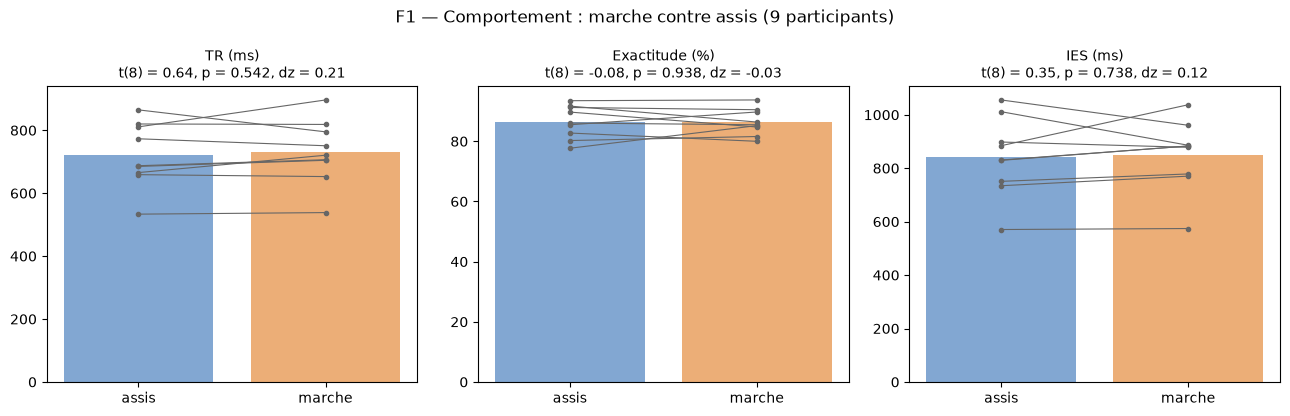

In [7]:
# ---- F1 : le comportement, condition par condition -------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, mesure in zip(axes, ['TR (ms)', 'Exactitude (%)', 'IES (ms)']):
    large = comport.pivot(index='participant', columns='condition', values=mesure)[[COND_A, COND_B]].dropna()   # qui a les deux conditions
    ax.bar([0, 1], large.mean(), color=[COULEURS[COND_A], COULEURS[COND_B]], alpha=0.6)    # la moyenne du groupe
    for participant, valeurs in large.iterrows():
        ax.plot([0, 1], valeurs.to_numpy(), color='0.4', lw=0.8, marker='o', ms=3)           # un trait par participant
    t, p = stats.ttest_rel(large[COND_B], large[COND_A])                                     # test t apparié
    difference = large[COND_B] - large[COND_A]
    dz = difference.mean() / difference.std(ddof=1)                                          # taille de l'effet
    ax.set_xticks([0, 1])
    ax.set_xticklabels([COND_A, COND_B])
    ax.set_title(f'{mesure}\nt({len(large) - 1}) = {t:.2f}, p = {p:.3f}, dz = {dz:.2f}', fontsize=10)
    bilan[f'F1 {mesure}'] = dict(n=len(large), difference_moyenne=round(difference.mean(), 2), t=round(t, 2), p=round(p, 4), dz=round(dz, 2))
fig.suptitle(f'F1 — Comportement : {COND_B} contre {COND_A} ({len(large)} participants)')
plt.tight_layout()
plt.show()

**Que regarder ? (F1)** Les barres sont les moyennes du groupe ; chaque trait relie les deux valeurs d'un participant. Si presque tous les
traits montent (ou descendent), l'effet est régulier et le test t est significatif même avec peu de participants.

**Questions.** (1) Avec l'hypothèse `'frequence'`, les mots rares sont-ils plus lents et moins exacts ? (2) Avec `'posture'`, la marche
ralentit-elle les réponses ? (3) Avec `'lexicalite'`, les pseudo-mots sont-ils plus lents ? plus souvent mal classés ? (4) Avec si peu de
participants, que veut dire un effet non significatif ?

<details><summary>Indices</summary>

(1) Oui, nettement : environ 75 ms de plus et 18 points d'exactitude de moins (les deux postures ensemble). (2) Très peu : une dizaine de
millisecondes, non significatif. (3) Plus lents d'environ 120 ms, mais pas moins exacts : décider « ce n'est pas un mot » prend du temps,
sans faire plus d'erreurs. (4) Pas que l'effet n'existe pas : avec 9 ou 10 participants, seul un grand effet peut être détecté. Regardez
aussi dz et les traits.
</details>

## 2. Les ERP moyens du groupe (Bloc Type 1)

Pour chaque participant, on fait la moyenne de ses époques dans chaque condition : c'est son **ERP**. Puis on fait la moyenne des ERP des
participants : l'**ERP du groupe**. La bande colorée autour de chaque courbe est l'intervalle de confiance à 95 % entre les participants. Les ERP
sont montrés pour la région choisie (`REGION`, section 0.4) : dans chaque époque, la moyenne de ses seules électrodes mesurées.

In [8]:
# ---- 2.1 L'ERP de chaque participant dans chaque condition -----------------------------------------------------------------------
MIN_EPOQUES = 20             # modifiable (v1.0 : 20) : un ERP de moins de 20 essais est trop bruité
erp_A, erp_B, onde_A, onde_B, participants = [], [], [], [], []   # par participant : l'ERP de chaque électrode, et celui de la région
for participant, ep in EPOQUES.items():                      # les époques choisies en 0.4
    e_a, e_b = ep[CHOIX_A], ep[CHOIX_B]                      # les essais de chaque condition
    if len(e_a) < MIN_EPOQUES or len(e_b) < MIN_EPOQUES:
        print(f'{participant} laissé de côté : {len(e_a)} essais {COND_A}, {len(e_b)} essais {COND_B}')
        continue
    for e, erp, onde in ((e_a, erp_A, onde_A), (e_b, erp_B, onde_B)):
        mesuree = np.array([[c not in str(r).split() for c in e.ch_names] for r in e.metadata['reconstruites']])   # essais x électrodes
        compte = mesuree.sum(axis=0)                         # le nombre d'essais où chaque électrode est mesurée
        moyenne = np.where(mesuree[:, :, None], e.get_data(), 0.0).sum(axis=0) / np.maximum(compte, 1)[:, None]
        moyenne[compte < MIN_EPOQUES] = np.nan               # une électrode trop peu mesurée n'a pas d'ERP (pas de carte à cet endroit)
        erp.append(mne.EvokedArray(moyenne, e.info, tmin=e.tmin, nave=len(e)))   # l'ERP de chaque électrode, sur ses essais mesurés
        onde.append(region_mesuree(e, REGION)[0].mean(axis=0))   # l'ERP de la région, chaque essai sans ses électrodes reconstruites (µV)
    participants.append(participant)
onde_A, onde_B = np.array(onde_A), np.array(onde_B)          # participants x temps : l'ERP de la région (µV)
temps = erp_A[0].times                                       # les instants de l'époque (s)
print(f'{len(participants)} participants : {", ".join(participants)}')

P005 laissé de côté : 0 essais assis, 182 essais marche
P006 laissé de côté : 304 essais assis, 0 essais marche


8 participants : P002, P003, P004, P007, P008, P009, P010, P012


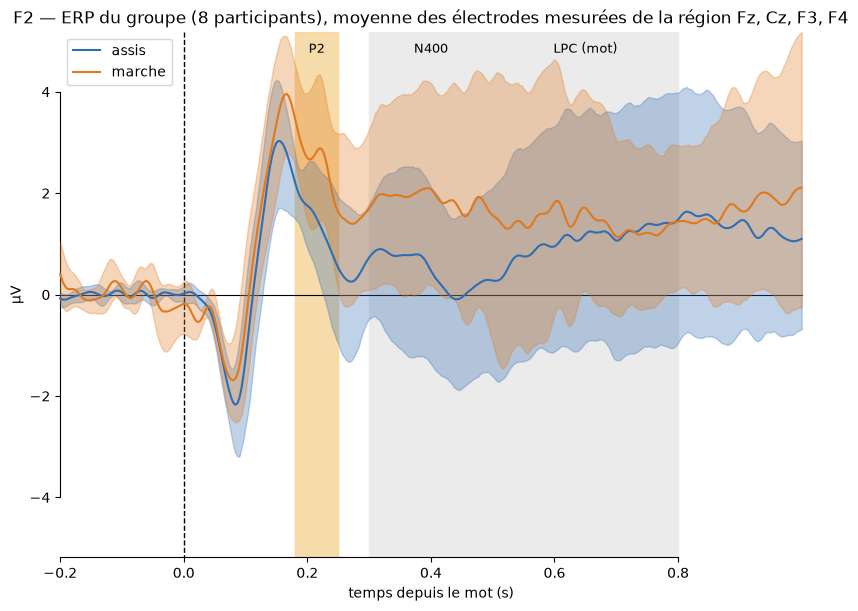

In [9]:
# ---- F2 : les ERP du groupe dans la région choisie -------------------------------------------------------------------------------
info_region = mne.create_info(['région'], erp_A[0].info['sfreq'], 'eeg')   # un seul « canal » : la région
courbes = {cond: [mne.EvokedArray(o[None, :] * 1e-6, info_region, tmin=temps[0]) for o in ondes]   # MNE travaille en volts
           for cond, ondes in ((COND_A, onde_A), (COND_B, onde_B))}
figures = mne.viz.plot_compare_evokeds(courbes, picks='région', ci=0.95, colors=COULEURS, show_sensors=False, show=False)
ax = figures[0].axes[0]
ax.set_title(f'F2 — ERP du groupe ({len(participants)} participants), moyenne des électrodes mesurées de la région {", ".join(REGION)}')
haut = ax.get_ylim()[1]
for nom, composante in COMPOSANTES.items():                  # les fenêtres des composantes qui ont le même zéro, en gris
    if composante['centre'] == CENTRE:
        ax.axvspan(*composante['fenetre'], color='0.92', zorder=0)
        ax.text(np.mean(composante['fenetre']), haut * 0.92, nom, ha='center', fontsize=9)
ax.axvspan(*FENETRE, color='#ffd27f', alpha=0.6, zorder=0)    # votre fenêtre, en jaune
ax.set_xlabel(f'temps depuis {ZERO} (s)')
plt.show()

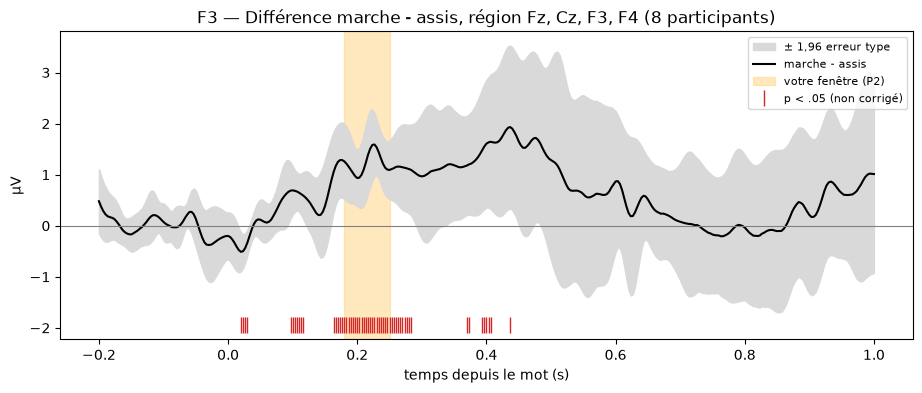

In [10]:
# ---- F3 : l'onde de différence (B - A) et un test t à chaque instant -------------------------------------------------------------
difference = onde_B - onde_A                                 # l'onde de différence de chaque participant
t_temps, p_temps = stats.ttest_rel(onde_B, onde_A, axis=0)   # un test t apparié à chaque instant
moyenne = difference.mean(axis=0)
erreur = difference.std(axis=0, ddof=1) / np.sqrt(len(difference))   # l'erreur type de la moyenne
fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(temps, moyenne - 1.96 * erreur, moyenne + 1.96 * erreur, color='0.85', label='± 1,96 erreur type')
ax.plot(temps, moyenne, color='k', label=f'{COND_B} - {COND_A}')
ax.axhline(0, color='0.5', lw=0.8)
ax.axvspan(*FENETRE, color='#ffd27f', alpha=0.5, zorder=0, label=f'votre fenêtre ({NOM})')
significatif = p_temps < 0.05
ax.plot(temps[significatif], np.full(significatif.sum(), ax.get_ylim()[0]), '|', color='C3', ms=12, label='p < .05 (non corrigé)')
ax.set_xlabel(f'temps depuis {ZERO} (s)')
ax.set_ylabel('µV')
ax.set_title(f'F3 — Différence {COND_B} - {COND_A}, région {", ".join(REGION)} ({len(difference)} participants)')
ax.legend(loc='upper right', fontsize=8)
plt.show()

**Que regarder ? (F2, F3)** Dans F2, les deux courbes se séparent-elles dans votre fenêtre ? Dans F3, l'onde de différence s'éloigne de 0 là où
les conditions diffèrent ; les traits rouges marquent les instants où le test t donne p < .05.

**Attention.** Avec 361 instants (301 pour les époques de la tape), on fait autant de tests : même sans aucun effet, environ 5 % d'entre
eux (18, ou 15) seraient significatifs par hasard. Ces traits sont donc *descriptifs* (on dit « non corrigés »). Le vrai test est celui
de la section 4, fait une seule fois, dans une fenêtre choisie à l'avance.

### F3b — Un test pour tous les instants à la fois : le test par amas (Bloc Type 3)

F3 fait un test par instant, sans correction. Le **test par amas** (*cluster*) de Maris et Oostenveld (2007) répond à la question pour toute
l'époque à la fois :
1. on garde les instants où le t dépasse le seuil d'un test à p < .05, et on regroupe les instants voisins en **amas** ;
2. chaque amas reçoit une masse : la somme de ses t ;
3. on recommence en changeant au hasard le signe de la différence de chaque participant (si les conditions ne diffèrent pas, B - A et
   A - B sont aussi probables). Avec 8 participants, il y a 256 façons de le faire, et le programme les essaie toutes ;
4. le p d'un amas est la part des tirages dont le plus gros amas pèse au moins autant que lui.

Un amas à p < .05 dit que les conditions diffèrent quelque part dans cet intervalle. Il ne dit pas exactement quand l'effet commence ou
finit : ses bords dépendent du seuil.

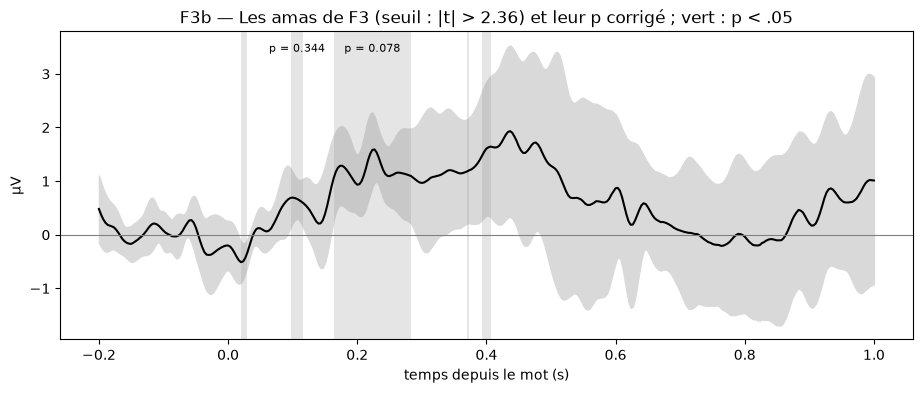

Amas : 20 à 30 ms (p = 0.555), 97 à 117 ms (p = 0.344), 163 à 283 ms (p = 0.078), 370 à 373 ms (p = 0.734), 393 à 407 ms (p = 0.516), 437 à 437 ms (p = 0.773)
Amas à p < .05 : aucun


In [11]:
# ---- F3b : le test par amas sur l'onde de différence de F3 -----------------------------------------------------------------------
from mne.stats import permutation_cluster_1samp_test           # le test par amas de MNE
SEUIL_T = stats.t.ppf(0.975, len(difference) - 1)            # le t d'un test bilatéral à p < .05 : il forme les amas
t_obs, amas, p_amas, _ = permutation_cluster_1samp_test(difference, threshold=SEUIL_T, n_permutations=1024, tail=0, out_type='mask',
                                                       seed=97, verbose=False)   # toutes les permutations des signes s'il y en a moins de 1024
fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(temps, moyenne - 1.96 * erreur, moyenne + 1.96 * erreur, color='0.85')
ax.plot(temps, moyenne, color='k', label=f'{COND_B} - {COND_A}')
ax.axhline(0, color='0.5', lw=0.8)
haut = ax.get_ylim()[1]
for masque, p_a in zip(amas, p_amas):                         # chaque amas : vert s'il est significatif, gris sinon
    ax.axvspan(temps[masque][0], temps[masque][-1], color='C2' if p_a < 0.05 else '0.6', alpha=0.25, lw=0)
    if temps[masque][-1] - temps[masque][0] >= 0.02:          # le p des amas d'au moins 20 ms (tous sont dans la sortie)
        ax.text(temps[masque].mean(), haut * 0.9, f'p = {p_a:.3f}', ha='center', fontsize=8)
ax.set_xlabel(f'temps depuis {ZERO} (s)')
ax.set_ylabel('µV')
ax.set_title(f'F3b — Les amas de F3 (seuil : |t| > {SEUIL_T:.2f}) et leur p corrigé ; vert : p < .05')
plt.show()
ordre = np.argsort([temps[m][0] for m in amas])                 # les amas dans l'ordre du temps
tous = [f'{temps[amas[k]][0] * 1000:.0f} à {temps[amas[k]][-1] * 1000:.0f} ms (p = {p_amas[k]:.3f})' for k in ordre]
significatifs = [a for a, k in zip(tous, ordre) if p_amas[k] < 0.05]
bilan['F3b amas à p < .05'] = dict(n=len(difference), amas=', '.join(significatifs) or 'aucun')
print('Amas :', ', '.join(tous) or 'aucun')
print('Amas à p < .05 :', ', '.join(significatifs) or 'aucun')

## 3. Les topographies (Bloc Type 1)

Une **topographie** montre l'amplitude moyenne dans votre fenêtre de temps sur tout le scalp, vue de dessus (le nez en haut). Rouge : positif ;
bleu : négatif. Les trois cartes ont la même échelle de couleurs. La carte de la différence montre *où* les conditions diffèrent.

Une électrode n'entre dans l'ERP d'un participant que dans les époques où elle a été mesurée. La carte du groupe donne, à chaque
électrode, la moyenne des participants qui l'ont mesurée, et seulement aux électrodes mesurées chez au moins 3 participants et la
moitié d'entre eux (comme dans le projet Brain Walk) ; les autres sont des cercles vides. P7, morte chez tous, n'a jamais de valeur.

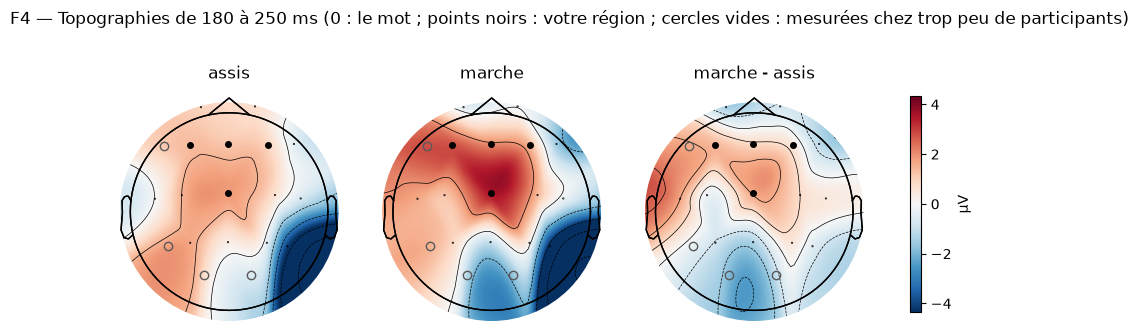

Le nombre de participants qui ont mesuré chaque électrode : {'Fp1': 5, 'Fp2': 5, 'F7': 3, 'F3': 7, 'Fz': 8, 'F4': 7, 'F8': 5, 'T7': 6, 'C3': 5, 'Cz': 8, 'C4': 7, 'T8': 7, 'P7': 0, 'P3': 7, 'Pz': 6, 'P4': 8, 'P8': 6, 'O1': 2, 'O2': 2}


In [12]:
# ---- F4 : les cartes des deux conditions et de leur différence -------------------------------------------------------------------
from matplotlib.colors import ListedColormap                 # une carte de couleurs transparente, pour les cercles vides
noms_ch = erp_A[0].ch_names
valeurs_A = np.array([e.copy().crop(*FENETRE).data.mean(axis=1) for e in erp_A]) * 1e6   # participants x électrodes (µV ; NaN : pas mesurée)
valeurs_B = np.array([e.copy().crop(*FENETRE).data.mean(axis=1) for e in erp_B]) * 1e6
deux = np.isfinite(valeurs_A) & np.isfinite(valeurs_B)       # le participant a mesuré l'électrode dans les deux conditions
n_mesure = deux.sum(axis=0)                                  # le nombre de participants qui l'ont mesurée
vue = n_mesure >= max(3, len(participants) / 2)              # la règle du projet : au moins 3 participants, et la moitié d'entre eux
cartes = [np.array([valeurs[deux[:, j], j].mean() if vue[j] else np.nan for j in range(len(noms_ch))])
          for valeurs in (valeurs_A, valeurs_B, valeurs_B - valeurs_A)]   # à chaque électrode, la moyenne des participants qui l'ont mesurée
limite = max(np.nanmax(np.abs(c)) for c in cartes)           # la même échelle pour les trois cartes
info_vue = mne.pick_info(erp_A[0].info, np.flatnonzero(vue))
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, carte, titre in zip(axes, cartes, [COND_A, COND_B, f'{COND_B} - {COND_A}']):
    image, _ = mne.viz.plot_topomap(carte[vue], info_vue, axes=ax, show=False, vlim=(-limite, limite), cmap='RdBu_r',
                                    mask=np.isin(np.array(noms_ch)[vue], REGION), mask_params=dict(marker='o', markerfacecolor='k', markersize=4))
    if not vue.all():                                        # les électrodes trop peu mesurées : des cercles vides, sans valeur
        mne.viz.plot_topomap(np.zeros(len(noms_ch)), erp_A[0].info, axes=ax, show=False, vlim=(-1, 1), cmap=ListedColormap([(0, 0, 0, 0)]),
                             contours=0, sensors=False, mask=~vue, mask_params=dict(marker='o', markerfacecolor='none', markeredgecolor='0.35', markersize=6))
    ax.set_title(titre)
fig.colorbar(image, ax=axes, shrink=0.7, label='µV')
fig.suptitle(f'F4 — Topographies de {FENETRE[0] * 1000:.0f} à {FENETRE[1] * 1000:.0f} ms (0 : {ZERO} ; points noirs : votre région ; '
             f'cercles vides : mesurées chez trop peu de participants)')
plt.show()
print('Le nombre de participants qui ont mesuré chaque électrode :', dict(zip(noms_ch, n_mesure.tolist())))

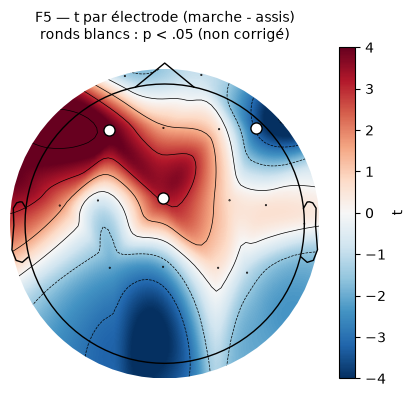

Électrodes à p < .05 : ['F3', 'F8', 'Cz']


In [13]:
# ---- F5 : un test t par électrode ------------------------------------------------------------------------------------------------
t_electrodes, p_electrodes = np.full(len(noms_ch), np.nan), np.full(len(noms_ch), np.nan)
for j in np.flatnonzero(vue):                                # un test t apparié par électrode, chez les participants qui l'ont mesurée
    t_electrodes[j], p_electrodes[j] = stats.ttest_rel(valeurs_B[deux[:, j], j], valeurs_A[deux[:, j], j])
fig, ax = plt.subplots(figsize=(5, 4.3))
image, _ = mne.viz.plot_topomap(t_electrodes[vue], info_vue, axes=ax, show=False, vlim=(-4, 4), cmap='RdBu_r', mask=p_electrodes[vue] < 0.05,
                                mask_params=dict(marker='o', markerfacecolor='w', markeredgecolor='k', markersize=8))
fig.colorbar(image, ax=ax, label='t')
ax.set_title(f'F5 — t par électrode ({COND_B} - {COND_A})\nronds blancs : p < .05 (non corrigé)', fontsize=10)
plt.show()
significatives = [c for c, p in zip(noms_ch, p_electrodes) if p < 0.05]
bilan['F5 électrodes à p < .05'] = dict(n=len(valeurs_A), electrodes=', '.join(significatives) or 'aucune')
print('Électrodes à p < .05 :', significatives or 'aucune')

**Que regarder ? (F4, F5)** La différence est-elle concentrée dans votre région, ou ailleurs ? Comme dans F3, 19 tests (un par électrode) sont
faits en même temps : un ou deux ronds blancs isolés peuvent venir du hasard.
Le nombre de participants derrière chaque électrode est dans la sortie de F4 : 8 pour Fz, Cz et P4, mais 5 pour Fp1, F8 ou C3, et 2
seulement pour O1 et O2 (qui n'ont pas de carte). Un test sur 5 participants est bien plus fragile qu'un test sur 8.

## 4. L'amplitude et la latence dans votre fenêtre (Bloc Type 1)

Pour chaque participant et chaque condition, on mesure sur l'ERP de la région :
- l'**amplitude moyenne** dans la fenêtre (en µV) : c'est la mesure la plus fiable, parce qu'elle moyenne beaucoup d'instants ;
- la **latence du pic** (en ms) : l'instant où l'ERP atteint son point le plus haut (composante positive) ou le plus bas (composante négative).
  On le cherche dans une fenêtre plus large (`FENETRE_LATENCE`, par exemple 130-320 ms pour la P2), parce que le pic d'un participant peut
  tomber un peu avant ou après la fenêtre d'amplitude. Un pic collé au bord de la fenêtre de recherche veut dire que le vrai pic est en
  dehors. Sur l'ERP d'un seul participant, le pic est bruité : la latence est une mesure fragile. Pour la LPC, les temps se comptent depuis
  la tape : une latence de -150 ms veut dire 150 ms avant la réponse.

La colonne **SME** donne la précision de l'amplitude de chaque participant : l'écart-type des amplitudes de ses essais divisé par la
racine de leur nombre (Luck et al., 2021 ; notebook 01, section 14). Plus elle est grande, moins l'amplitude est sûre.

Puis on compare les deux conditions avec un test t apparié, une seule fois par mesure : c'est le test principal de votre hypothèse.

In [14]:
# ---- 4.1 Amplitude, latence et précision (SME) de chaque participant -------------------------------------------------------------
lignes = []
for participant, o_a, o_b in zip(participants, onde_A, onde_B):
    for condition, onde, choix in ((COND_A, o_a, CHOIX_A), (COND_B, o_b, CHOIX_B)):   # onde : l'ERP de la région (µV, section 2.1)
        dans = (temps >= FENETRE[0]) & (temps <= FENETRE[1])     # les instants de la fenêtre d'amplitude
        amplitude = onde[dans].mean()                            # l'amplitude moyenne dans la fenêtre
        cherche = (temps >= FENETRE_LATENCE[0]) & (temps <= FENETRE_LATENCE[1])   # la fenêtre de recherche du pic
        pic = onde[cherche].argmax() if POLARITE == 'positive' else onde[cherche].argmin()   # le point le plus haut (ou le plus bas)
        latence = temps[cherche][pic] * 1000                     # sa latence, en ms
        par_essai = region_mesuree(EPOQUES[participant][choix].copy().crop(*FENETRE), REGION)[0].mean(axis=1)   # la région, essai par essai
        sme = par_essai.std(ddof=1) / np.sqrt(len(par_essai))   # la SME : l'écart-type des essais divisé par la racine de leur nombre
        lignes.append({'participant': participant, 'condition': condition, 'amplitude (µV)': amplitude, 'latence (ms)': latence,
                       'SME (µV)': sme, 'essais': len(par_essai)})
mesures_eeg = pd.DataFrame(lignes)
mesures_eeg.round(2)

,participant,condition,amplitude (µV),latence (ms),SME (µV),essais
0,P002,assis,1.40,143.33,0.37,324
1,P002,marche,3.23,320.00,0.65,313
2,P003,assis,2.53,270.00,0.25,358
3,P003,marche,2.98,230.00,0.51,317
4,P004,assis,3.04,320.00,0.35,285
5,P004,marche,5.09,176.67,1.59,214
6,P007,assis,0.46,166.67,0.26,318
7,P007,marche,0.98,160.00,0.70,199
8,P008,assis,0.21,203.33,0.31,330
9,P008,marche,2.27,220.00,0.62,294


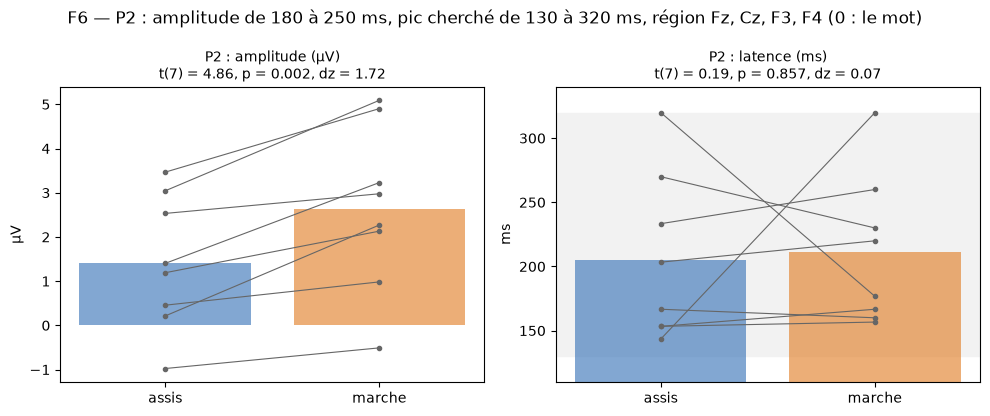

In [15]:
# ---- F6 : amplitude et latence, condition par condition --------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, mesure, unite in zip(axes, ['amplitude (µV)', 'latence (ms)'], ['µV', 'ms']):
    large = mesures_eeg.pivot(index='participant', columns='condition', values=mesure)[[COND_A, COND_B]]
    ax.bar([0, 1], large.mean(), color=[COULEURS[COND_A], COULEURS[COND_B]], alpha=0.6)
    for participant, valeurs in large.iterrows():
        ax.plot([0, 1], valeurs.to_numpy(), color='0.4', lw=0.8, marker='o', ms=3)
    t, p = stats.ttest_rel(large[COND_B], large[COND_A])
    difference = large[COND_B] - large[COND_A]
    dz = difference.mean() / difference.std(ddof=1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([COND_A, COND_B])
    ax.set_ylabel(unite)
    ax.set_title(f'{NOM} : {mesure}\nt({len(large) - 1}) = {t:.2f}, p = {p:.3f}, dz = {dz:.2f}', fontsize=10)
    bilan[f'F6 {NOM} {mesure}'] = dict(n=len(large), difference_moyenne=round(difference.mean(), 2), t=round(t, 2), p=round(p, 4),
                                       dz=round(dz, 2))
axes[1].axhspan(FENETRE_LATENCE[0] * 1000, FENETRE_LATENCE[1] * 1000, color='0.95', zorder=0)   # la fenêtre de recherche du pic
axes[1].set_ylim(FENETRE_LATENCE[0] * 1000 - 20, FENETRE_LATENCE[1] * 1000 + 20)
fig.suptitle(f'F6 — {NOM} : amplitude de {FENETRE[0] * 1000:.0f} à {FENETRE[1] * 1000:.0f} ms, pic cherché de '
             f'{FENETRE_LATENCE[0] * 1000:.0f} à {FENETRE_LATENCE[1] * 1000:.0f} ms, région {", ".join(REGION)} (0 : {ZERO})')
plt.tight_layout()
plt.show()

**Que regarder ? (F6)** Le sens de la différence correspond-il à votre prédiction ? Pour une composante négative comme la N400, une valeur plus
négative veut dire une onde plus *grande*.

Comparez aussi la colonne SME de 4.1 entre les postures : pour la P2, elle est plus grande en marche chez les 8 participants qui ont les
deux postures (moins d'essais, et un signal plus agité). Une condition moins précise pèse autant que l'autre dans le test t : c'est une
raison de plus de regarder les traits de chaque participant.

**Bloc Type 2.** Refaites la section 4 avec les trois composantes, pour chaque hypothèse (changez `COMPOSANTE` et `HYPOTHESE` à la section 0.4
et relancez tout). Notez les résultats dans un tableau. Pour la LPC, refaites-la avec `SANS_CLIGNEMENT = True`, puis avec
`'LPC (mot)'` : l'effet change-t-il ?

*Pour aller plus loin.* Les articles mesurent souvent la latence par la méthode du *jackknife* (Miller, Patterson et Ulrich, 1998) : la latence
est mesurée sur la moyenne du groupe sans un participant, en retirant chaque participant à tour de rôle, ce qui est bien moins bruité que le
pic d'un seul participant.

## 5. La marche change-t-elle l'effet des mots ? (Bloc Type 2)

**Pourquoi cette section ?** Les sections 2 à 4 testent un facteur à la fois. La question du projet Brain Walk les croise : **l'effet de la
fréquence (ou de la lexicalité) change-t-il quand on marche ?** Si marcher prend de l'attention, l'accès au sens des mots pourrait en
souffrir, et l'effet serait plus petit en marche. C'est une **interaction** entre la posture et le type de mot.

Pour chaque participant, on mesure l'effet dans chaque posture (par exemple LF - HF assis, et LF - HF en marche), dans la fenêtre et la
région choisies en 0.4, puis on compare les deux effets avec un test t apparié. Dans un plan 2 x 2 comme celui-ci, c'est le test de
l'interaction. On teste aussi chaque effet contre 0 : existe-t-il assis ? en marche ?

In [16]:
# ---- 5.1 L'effet dans chaque posture ---------------------------------------------------------------------------------------------
EFFET = 'frequence'          # modifiable : 'frequence' (LF - HF) ou 'lexicalite' (pseudo-mots - mots)
TYPES_A, TYPES_B = (['HF'], ['LF']) if EFFET == 'frequence' else (['HF', 'LF'], ['pseudo'])
NOM_EFFET = 'LF - HF' if EFFET == 'frequence' else 'pseudo-mots - mots'
lignes_i = []
for participant, ep in EPOQUES.items():
    effets = {}
    for posture in ('assis', 'marche'):
        e_a = ep[[f'{posture}/{t}' for t in TYPES_A]]            # les époques de cette posture pour chaque condition
        e_b = ep[[f'{posture}/{t}' for t in TYPES_B]]
        if min(len(e_a), len(e_b)) < MIN_EPOQUES:
            continue                                             # trop peu d'essais : pas d'effet dans cette posture
        a_ = region_mesuree(e_a.copy().crop(*FENETRE), REGION)[0].mean()   # l'amplitude moyenne, électrodes mesurées seulement (µV)
        b_ = region_mesuree(e_b.copy().crop(*FENETRE), REGION)[0].mean()
        effets[posture] = b_ - a_
    if len(effets) == 2:                                         # seulement les participants qui ont les deux postures
        lignes_i.append({'participant': participant, 'assis': effets['assis'], 'marche': effets['marche']})
interaction = pd.DataFrame(lignes_i).set_index('participant')
print(f'{NOM} : l\'effet {NOM_EFFET} (µV) de chaque participant, dans chaque posture')
interaction.round(2)

P2 : l'effet LF - HF (µV) de chaque participant, dans chaque posture


,assis,marche
participant,,
P002,1.23,1.47
P003,-0.06,-2.62
P004,-0.54,-2.30
P007,0.57,-1.13
P008,0.40,1.55
P009,-0.55,3.82
P010,0.23,0.13
P012,0.81,1.07


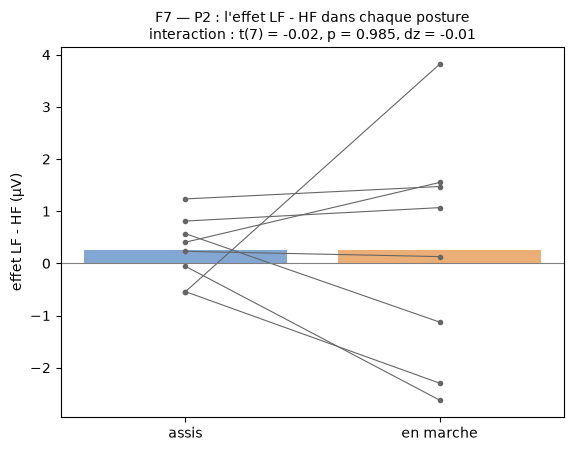

assis : effet LF - HF = +0.26 µV, t(7) = 1.19, p = 0.274
marche : effet LF - HF = +0.25 µV, t(7) = 0.32, p = 0.756


In [17]:
# ---- F7 : l'effet dans chaque posture, et l'interaction --------------------------------------------------------------------------
t_i, p_i = stats.ttest_rel(interaction['marche'], interaction['assis'])   # l'interaction : l'effet change-t-il avec la posture ?
difference_i = interaction['marche'] - interaction['assis']
dz_i = difference_i.mean() / difference_i.std(ddof=1)
fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.bar([0, 1], interaction.mean(), color=['#2f6db5', '#e0791d'], alpha=0.6)
for participant, valeurs in interaction.iterrows():
    ax.plot([0, 1], valeurs.to_numpy(), color='0.4', lw=0.8, marker='o', ms=3)   # un trait par participant
ax.axhline(0, color='0.5', lw=0.8)
ax.set_xticks([0, 1])
ax.set_xticklabels(['assis', 'en marche'])
ax.set_ylabel(f'effet {NOM_EFFET} (µV)')
ax.set_title(f'F7 — {NOM} : l\'effet {NOM_EFFET} dans chaque posture\n'
             f'interaction : t({len(interaction) - 1}) = {t_i:.2f}, p = {p_i:.3f}, dz = {dz_i:.2f}', fontsize=10)
plt.show()
for posture in ('assis', 'marche'):                              # chaque effet contre 0
    t_p, p_p = stats.ttest_1samp(interaction[posture], 0.0)
    print(f'{posture} : effet {NOM_EFFET} = {interaction[posture].mean():+.2f} µV, t({len(interaction) - 1}) = {t_p:.2f}, p = {p_p:.3f}')
    bilan[f'F7 effet {NOM_EFFET}, {posture} ({NOM})'] = dict(n=len(interaction), difference_moyenne=round(interaction[posture].mean(), 2),
                                                           t=round(t_p, 2), p=round(p_p, 4))
bilan[f'F7 interaction posture x {EFFET} ({NOM})'] = dict(n=len(interaction), difference_moyenne=round(difference_i.mean(), 2),
                                                        t=round(t_i, 2), p=round(p_i, 4), dz=round(dz_i, 2))

**Que regarder ? (F7)** Chaque trait relie l'effet d'un participant assis et son effet en marche. Si la marche réduit l'effet, les traits
descendent vers 0 ; si elle le change au hasard, ils se croisent dans tous les sens. Deux choses à séparer :
- **l'effet existe-t-il dans chaque posture ?** C'est le test de chaque effet contre 0, dans la sortie ;
- **est-il différent entre les postures ?** C'est le test de l'interaction, dans le titre.

Un effet significatif assis et non significatif en marche ne montre pas une interaction : il faut que la différence entre les deux effets
soit elle-même significative. Et avec 8 participants, seule une grande interaction peut être détectée : un résultat non significatif ne
prouve pas que la marche ne change rien.

**Bloc Type 2.** Mettez `EFFET = 'lexicalite'` (cellule 5.1) et `COMPOSANTE = 'LPC'` (section 0.4), puis relancez tout : l'effet des
pseudo-mots sur la LPC existe-t-il dans les deux postures ? Change-t-il avec la posture ?

## 6. Le comportement et l'EEG vont-ils ensemble ? (Bloc Type 2)

On cherche si les participants qui ont le plus grand effet dans le comportement ont aussi le plus grand effet dans l'EEG. Chaque point est un
participant. Deux corrélations :
- **Pearson (r)** : mesure une relation en ligne droite ; un seul point extrême peut la changer beaucoup ;
- **Spearman (ρ)** : utilise les rangs ; elle résiste mieux à un point extrême.

**Attention.** Avec 8 à 10 points, une corrélation est très incertaine : même un r de 0,6 peut venir du hasard. Regardez le nuage de points
avant de croire le chiffre.

In [18]:
# ---- 6.1 Vos choix pour la corrélation -------------------------------------------------------------------------------------------
COMPORTEMENT = 'TR (ms)'     # modifiable : 'TR (ms)', 'Exactitude (%)' ou 'IES (ms)'
MESURE_EEG = 'amplitude (µV)'   # modifiable : 'amplitude (µV)' ou 'latence (ms)'
VALEURS = 'difference'       # modifiable : 'difference' (B - A de chaque participant), ou une condition : COND_A ou COND_B
large_c = comport.pivot(index='participant', columns='condition', values=COMPORTEMENT)
large_e = mesures_eeg.pivot(index='participant', columns='condition', values=MESURE_EEG)
if VALEURS == 'difference':
    x, y = large_c[COND_B] - large_c[COND_A], large_e[COND_B] - large_e[COND_A]   # l'effet de chaque participant
else:
    x, y = large_c[VALEURS], large_e[VALEURS]                                     # les valeurs d'une condition
points = pd.DataFrame({'comportement': x, 'eeg': y}).dropna()                     # les participants qui ont les deux
r, p_r = stats.pearsonr(points['comportement'], points['eeg'])
rho, p_rho = stats.spearmanr(points['comportement'], points['eeg'])
pente, ordonnee = np.polyfit(points['comportement'], points['eeg'], 1)            # la droite qui passe au mieux par les points
bilan[f'F8 {COMPORTEMENT} et {MESURE_EEG} ({VALEURS})'] = dict(n=len(points), r=round(r, 2), p=round(p_r, 4), rho=round(rho, 2), p_rho=round(p_rho, 4))
points.round(2)

,comportement,eeg
participant,,
P002,19.11,1.83
P003,19.46,0.44
P004,-1.45,2.05
P007,55.20,0.53
P008,-69.84,2.06
P009,-22.16,1.44
P010,85.56,0.47
P012,4.96,0.94


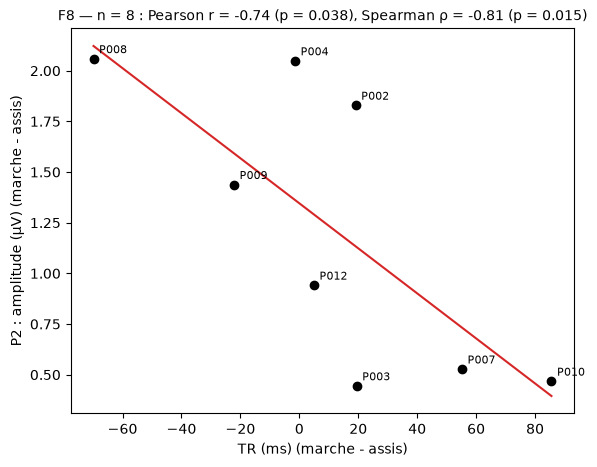

In [19]:
# ---- F8 : le nuage de points -----------------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(points['comportement'], points['eeg'], color='k')
for participant, ligne in points.iterrows():
    ax.annotate(participant, (ligne['comportement'], ligne['eeg']), fontsize=8, xytext=(4, 4), textcoords='offset points')
xs = np.linspace(points['comportement'].min(), points['comportement'].max(), 50)
ax.plot(xs, pente * xs + ordonnee, color='C3')
suffixe = f' ({COND_B} - {COND_A})' if VALEURS == 'difference' else f' ({VALEURS})'
ax.set_xlabel(COMPORTEMENT + suffixe)
ax.set_ylabel(f'{NOM} : {MESURE_EEG}' + suffixe)
ax.set_title(f'F8 — n = {len(points)} : Pearson r = {r:.2f} (p = {p_r:.3f}), Spearman ρ = {rho:.2f} (p = {p_rho:.3f})', fontsize=10)
plt.show()

## 7. Synthèse (Bloc Type 1)

Le tableau réunit tous les tests faits avec vos derniers choix. Relancez le notebook avec d'autres choix pour compléter votre tableau de
résultats.

In [20]:
# ---- 7.1 Tous vos tests ----------------------------------------------------------------------------------------------------------
print(f'Hypothèse « {HYPOTHESE} » ({COND_B} - {COND_A}), {NOM}, de {FENETRE[0] * 1000:.0f} à {FENETRE[1] * 1000:.0f} ms (0 : {ZERO}), '
      f'région {", ".join(REGION)}')
pd.DataFrame.from_dict(bilan, orient='index')                # une ligne par test

Hypothèse « posture » (marche - assis), P2, de 180 à 250 ms (0 : le mot), région Fz, Cz, F3, F4


,n,difference_moyenne,t,p,dz,amas,electrodes,r,rho,p_rho
F1 TR (ms),9,9.42,0.64,0.5420,0.21,NaN,NaN,NaN,NaN,NaN
F1 Exactitude (%),9,-0.11,-0.08,0.9383,-0.03,NaN,NaN,NaN,NaN,NaN
F1 IES (ms),9,9.64,0.35,0.7376,0.12,NaN,NaN,NaN,NaN,NaN
F3b amas à p < .05,8,NaN,NaN,NaN,NaN,aucun,NaN,NaN,NaN,NaN
F5 électrodes à p < .05,8,NaN,NaN,NaN,NaN,NaN,"F3, F8, Cz",NaN,NaN,NaN
F6 P2 amplitude (µV),8,1.22,4.86,0.0018,1.72,NaN,NaN,NaN,NaN,NaN
F6 P2 latence (ms),8,5.83,0.19,0.8567,0.07,NaN,NaN,NaN,NaN,NaN
"F7 effet LF - HF, assis (P2)",8,0.26,1.19,0.2738,NaN,NaN,NaN,NaN,NaN,NaN
"F7 effet LF - HF, marche (P2)",8,0.25,0.32,0.7558,NaN,NaN,NaN,NaN,NaN,NaN
F7 interaction posture x frequence (P2),8,-0.01,-0.02,0.9854,-0.01,NaN,NaN,NaN,NaN,NaN


**Pour votre rapport.**
1. Énoncez votre hypothèse et vos prédictions (comportement, composante, sens de l'effet) *avant* de présenter les résultats.
2. Pour chaque test, rapportez la moyenne de chaque condition, la différence, t(ddl), p et dz, et le nombre de participants.
3. Décrivez les figures F2 à F5 : où et quand les conditions diffèrent-elles ? Le test par amas (F3b) confirme-t-il F3 ?
4. Rapportez l'interaction (F7) : l'effet des mots est-il le même assis et en marche ?
5. Discutez les limites : le petit nombre de participants, les tests non corrigés de F3 et F5, la fragilité de la latence du pic, les
   clignements près de la tape pour la LPC (comparez avec `SANS_CLIGNEMENT = True`), les électrodes reconstruites (section 0.5) et ce que la marche change à la qualité du signal
   (voir le notebook 01).

<details><summary>Indices</summary>

Avec l'hypothèse `'posture'` et la P2, l'onde est plus grande en marche chez les 8 participants qui ont les deux postures (F6, p = .002).
Pourtant, le test par amas de F3b ne trouve pas d'amas significatif (le plus gros, de 163 à 283 ms, a p = .078) : un test sur toute
l'époque est plus prudent qu'un test dans une fenêtre choisie à l'avance. Avec `'frequence'`, les effets sont nets dans le comportement,
pas dans la N400. Avec `'lexicalite'` et la LPC (autour de la tape), la LPC est plus petite pour les pseudo-mots, assis et en marche
(section 5), sans interaction significative.
</details>

**La suite.** Le notebook 10 analyse les rythmes de l'EEG (spectres et temps-fréquence) et le notebook 11 l'apprentissage machine, sur les
mêmes participants.

### Références

- Kutas, M., & Federmeier, K. D. (2011). Thirty years and counting: Finding meaning in the N400 component of the event-related brain potential (ERP). *Annual Review of Psychology, 62*, 621-647. https://doi.org/10.1146/annurev.psych.093008.131123
- Luck, S. J., Stewart, A. X., Simmons, A. M., & Rhemtulla, M. (2021). Standardized measurement error: A universal metric of data quality for averaged event-related potentials. *Psychophysiology, 58*, e13793. https://doi.org/10.1111/psyp.13793
- Maris, E., & Oostenveld, R. (2007). Nonparametric statistical testing of EEG- and MEG-data. *Journal of Neuroscience Methods, 164*, 177-190. https://doi.org/10.1016/j.jneumeth.2007.03.024
- Miller, J., Patterson, T., & Ulrich, R. (1998). Jackknife-based method for measuring LRP onset latency differences. *Psychophysiology, 35*, 99-115. https://doi.org/10.1111/1469-8986.3510099
- Twomey, D. M., Murphy, P. R., Kelly, S. P., & O'Connell, R. G. (2015). The classic P300 encodes a build-to-threshold decision variable. *European Journal of Neuroscience, 42*, 1636-1643. https://doi.org/10.1111/ejn.12936